In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load Dataset
df = pd.read_csv("/content/Ecommerce_Customer_Behavior (2).csv")
df.head()

,Customer_ID,Age,Device_Type,Session_Duration,Pages_Viewed,Purchase_Amount,Membership_Level
0,CUST1000,56,Mobile,28.45,8,436.72,Gold
1,CUST1001,46,Tablet,1.81,1,40.27,NaN
2,CUST1002,32,Tablet,5.81,2,427.86,NaN
3,CUST1003,60,Tablet,16.26,18,391.91,NaN
4,CUST1004,25,Desktop,2.64,15,56.24,Gold


In [ ]:
#Dataset Overview
df.shape


(1000, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       1000 non-null   object 
 1   Age               1000 non-null   int64  
 2   Device_Type       1000 non-null   object 
 3   Session_Duration  1000 non-null   float64
 4   Pages_Viewed      1000 non-null   int64  
 5   Purchase_Amount   1000 non-null   float64
 6   Membership_Level  754 non-null    object 
dtypes: float64(2), int64(2), object(3)
memory usage: 54.8+ KB


In [ ]:
df.describe()

,Age,Session_Duration,Pages_Viewed,Purchase_Amount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.986000,29.903300,9.933000,259.052120
std,13.497852,16.882898,5.519327,144.030604
min,18.000000,1.000000,1.000000,5.900000
25%,29.000000,15.172500,5.000000,135.922500
50%,42.000000,29.870000,10.000000,265.980000
75%,52.000000,44.125000,15.000000,386.727500
max,64.000000,59.870000,19.000000,499.870000


In [ ]:
#Check Missing Values
df.isnull().sum()

,0
Customer_ID,0
Age,0
Device_Type,0
Session_Duration,0
Pages_Viewed,0
Purchase_Amount,0
Membership_Level,246


In [ ]:
# Treat Missingvalue
df["Membership_Level"] = df["Membership_Level"].fillna("None")
df.isnull().sum()

,0
Customer_ID,0
Age,0
Device_Type,0
Session_Duration,0
Pages_Viewed,0
Purchase_Amount,0
Membership_Level,0


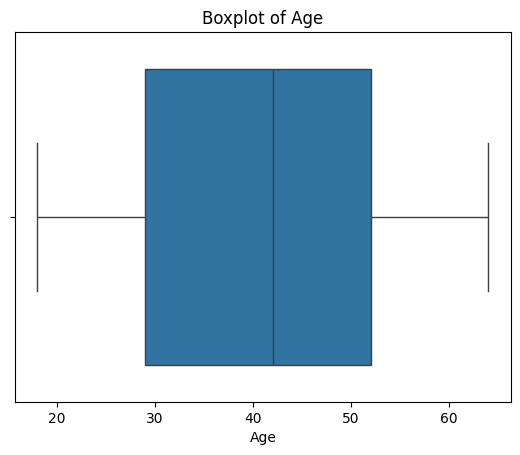

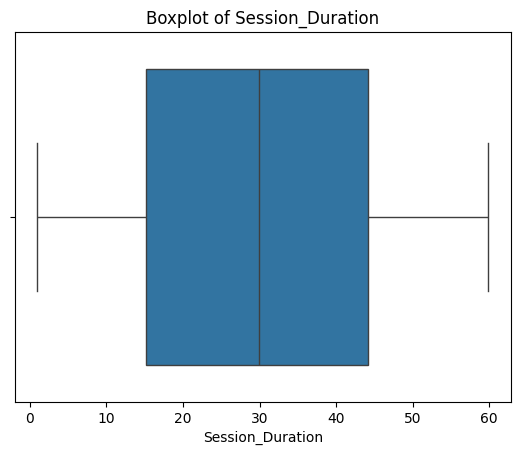

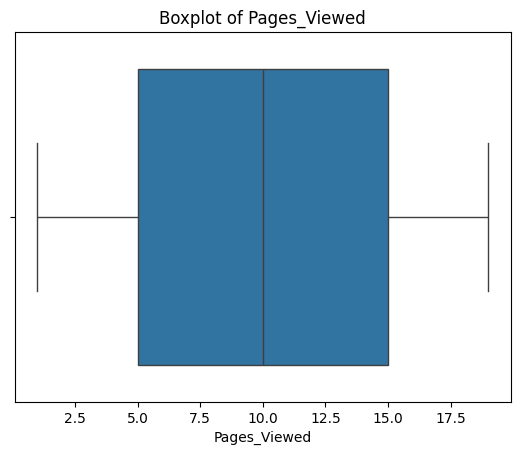

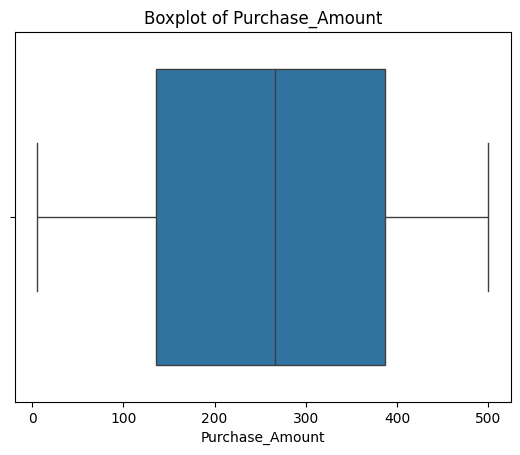

In [ ]:
#Outlier Detection
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age','Session_Duration','Pages_Viewed','Purchase_Amount']

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, "Outliers:", outliers.shape[0])

Age Outliers: 0
Session_Duration Outliers: 0
Pages_Viewed Outliers: 0
Purchase_Amount Outliers: 0


In [ ]:
# No Outlier Treatment Need

In [ ]:
# BUSSINESS PROBLEMS

In [ ]:
# 1. Which device type is mostly used by customers who make the highest purchase?
df.groupby("Device_Type")["Purchase_Amount"].mean()

,Purchase_Amount
Device_Type,
Desktop,258.832646
Mobile,248.407667
Tablet,269.440522


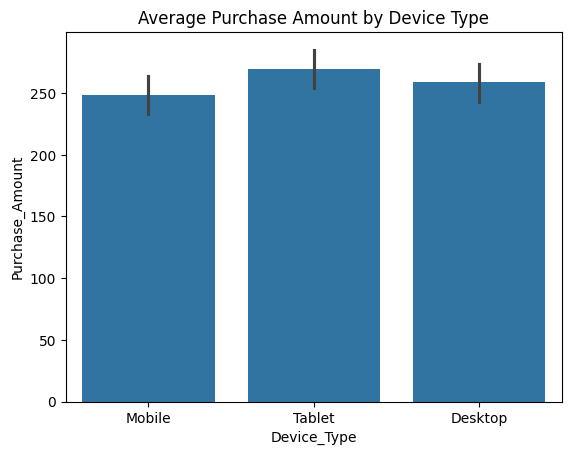

In [ ]:
sns.barplot(x="Device_Type",y="Purchase_Amount",data=df)
plt.title("Average Purchase Amount by Device Type")
plt.show()

Age_Group
18-25    152
26-35    192
36-45    231
46-55    223
56-65    177
Name: count, dtype: int64


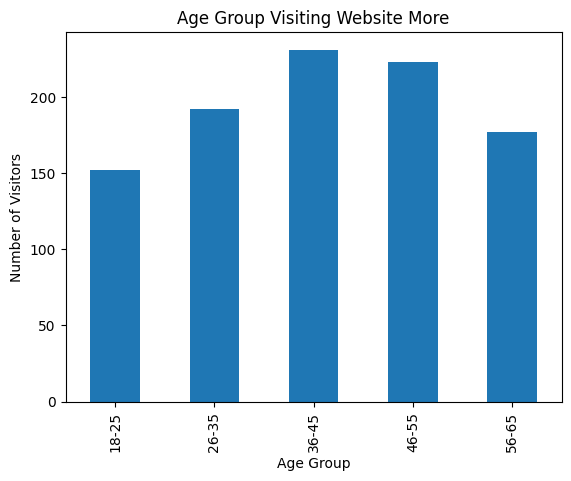

In [ ]:
# 2.Which age group of customers visit the website more?

import pandas as pd
import matplotlib.pyplot as plt

# Create Age Groups
bins = [18,25,35,45,55,65]
labels = ['18-25','26-35','36-45','46-55','56-65']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Count visitors in each age group
age_group_count = df['Age_Group'].value_counts().sort_index()

print(age_group_count)

# Plot graph
age_group_count.plot(kind='bar')
plt.xlabel("Age Group")
plt.ylabel("Number of Visitors")
plt.title("Age Group Visiting Website More")
plt.show()

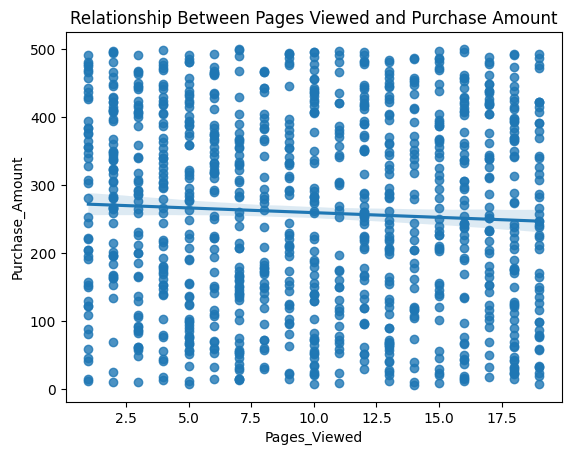

In [ ]:
# 3.Customers who view few pages spend less or more money?
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x="Pages_Viewed", y="Purchase_Amount", data=df)
plt.title("Relationship Between Pages Viewed and Purchase Amount")
plt.show()

In [ ]:
# It indicating browsing more pages does not guarantee higher spending.

In [ ]:
# 4. Which device type users have the lowest session duration?
df.groupby("Device_Type")["Session_Duration"].mean()

,Session_Duration
Device_Type,
Desktop,28.709969
Mobile,31.481939
Tablet,29.517449


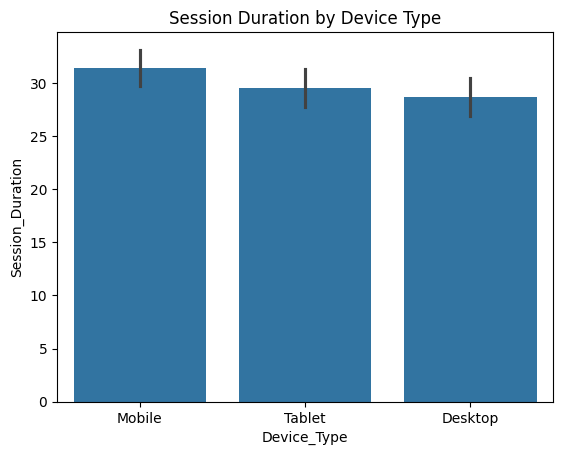

In [ ]:
sns.barplot(x="Device_Type",y="Session_Duration",data=df)
plt.title("Session Duration by Device Type")
plt.show()

In [ ]:
# 5. Which membership level has the highest purchase amount?
df.groupby("Membership_Level")["Purchase_Amount"].mean()

,Purchase_Amount
Membership_Level,
Gold,265.340119
None,245.966138
Platinum,259.508258
Silver,265.414430


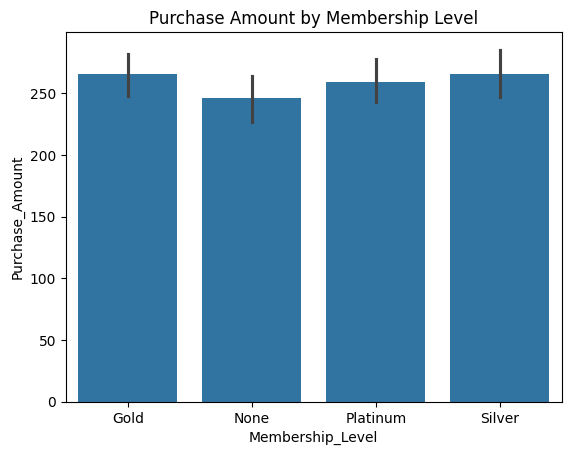

In [ ]:
sns.barplot(x="Membership_Level",y="Purchase_Amount",data=df)
plt.title("Purchase Amount by Membership Level")
plt.show()

In [ ]:
# 6. Does age affect membership level?
pd.crosstab(df["Age_Group"],df["Membership_Level"])

Membership_Level,Gold,None,Platinum,Silver
Age_Group,,,,
18-25,35,43,38,36
26-35,43,49,51,49
36-45,71,54,49,57
46-55,61,40,68,54
56-65,37,54,52,34


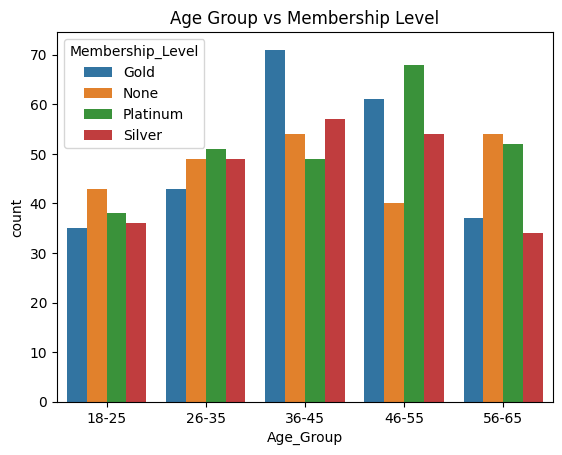

In [ ]:
sns.countplot(x="Age_Group",hue="Membership_Level",data=df)
plt.title("Age Group vs Membership Level")
plt.show()

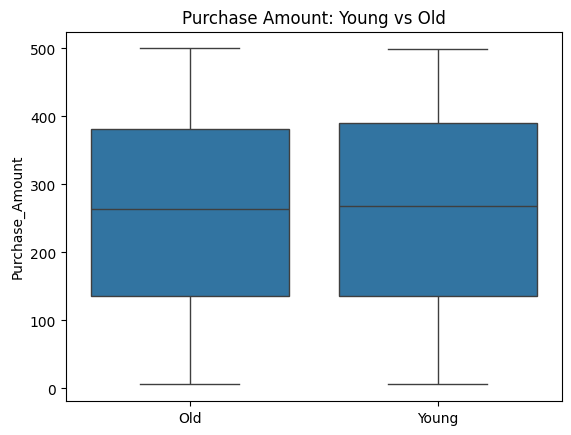

In [ ]:
# 7.Difference in purchase amount between younger and older customers
young = df[df["Age"] < 35]["Purchase_Amount"]
old = df[df["Age"] >= 35]["Purchase_Amount"]

young.mean(), old.mean()

sns.boxplot(x=np.where(df["Age"] < 35, "Young", "Old"),
            y=df["Purchase_Amount"])

plt.title("Purchase Amount: Young vs Old")
plt.show()

In [ ]:
# 8.Which membership level has the highest number of customers?
df["Membership_Level"].value_counts()

,count
Membership_Level,
Platinum,264
Gold,253
None,246
Silver,237


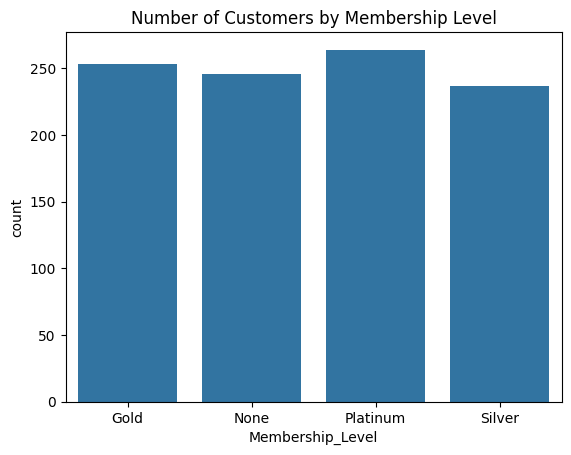

In [ ]:
sns.countplot(x="Membership_Level",data=df)
plt.title("Number of Customers by Membership Level")
plt.show()

In [ ]:
# 9.Which membership level has the highest session duration?
df.groupby("Membership_Level")["Session_Duration"].mean().sort_values(ascending=False)

,Session_Duration
Membership_Level,
None,31.095732
Gold,30.789763
Platinum,29.682803
Silver,27.964895


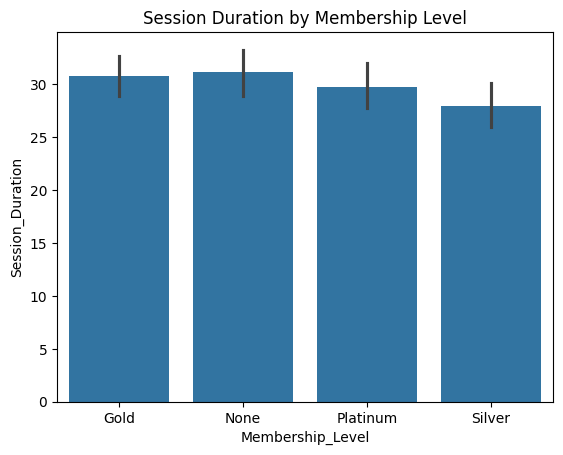

In [ ]:
sns.barplot(x="Membership_Level",y="Session_Duration",data=df)
plt.title("Session Duration by Membership Level")
plt.show()

In [ ]:
# 10. Relationship between Device Type and Membership Level
pd.crosstab(df["Device_Type"],df["Membership_Level"])

Membership_Level,Gold,None,Platinum,Silver
Device_Type,,,,
Desktop,95,74,82,74
Mobile,74,85,88,83
Tablet,84,87,94,80


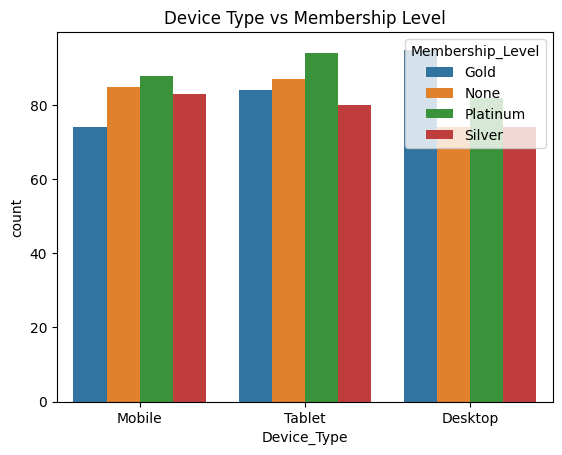

In [ ]:
sns.countplot(x="Device_Type",hue="Membership_Level",data=df)
plt.title("Device Type vs Membership Level")
plt.show()

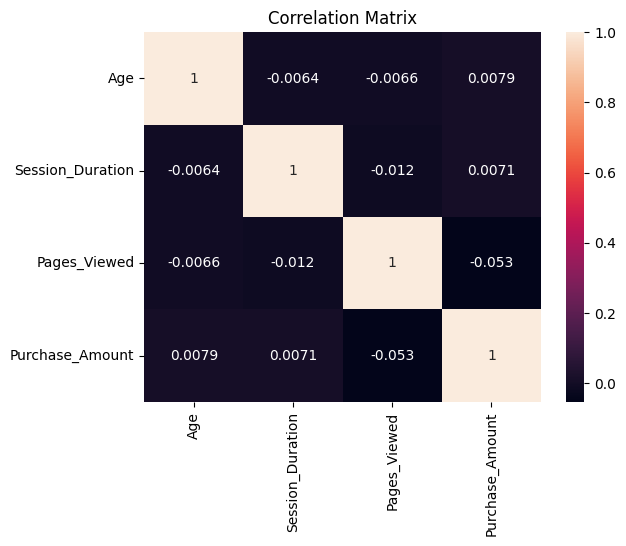

In [ ]:
# Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# T-Test
from scipy.stats import ttest_ind

young = df[df["Age"] < 35]["Purchase_Amount"]
old = df[df["Age"] >= 35]["Purchase_Amount"]

t_stat, p_value = ttest_ind(young, old)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Decision using if-else
if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("There is a significant difference in purchase amount between young and old customers.")
else:
    print("Fail to Reject Null Hypothesis")
    print("There is no significant difference in purchase amount between young and old customers.")

T-statistic: 0.09750468605577235
P-value: 0.9223451908870776
Fail to Reject Null Hypothesis
There is no significant difference in purchase amount between young and old customers.


In [ ]:
#Young and old customers spend almost the same amount on the website.

In [ ]:
#Chi-square test
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Device_Type"], df["Membership_Level"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p)

# Decision using if-else
if p < 0.05:
    print("Reject Null Hypothesis")
    print("There is a significant relationship between Device Type and Membership Level.")
else:
    print("Fail to Reject Null Hypothesis")
    print("There is no significant relationship between Device Type and Membership Level.")

Chi-square: 4.5842168386535915
P-value: 0.5981326211215883
Fail to Reject Null Hypothesis
There is no significant relationship between Device Type and Membership Level.


In [ ]:
# The relationship is not significant because the membership distribution is similar across all device types.

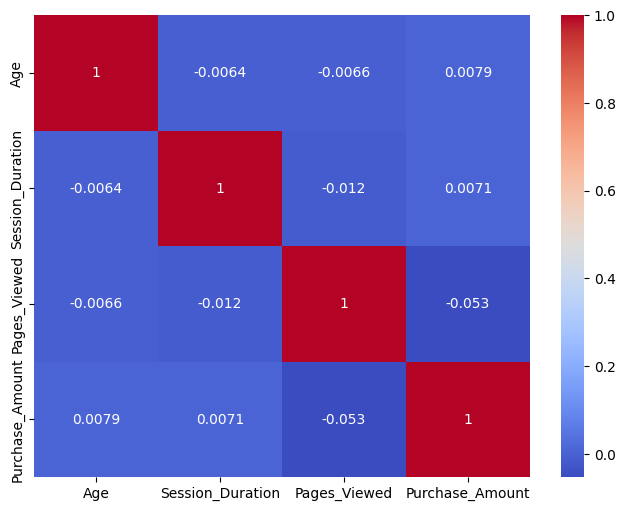

In [ ]:
# Feature Selection
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
# The correlation heatmap shows that the relationships between independent variables and purchase amount are weak,
# indicating that no single feature strongly influences the purchase amount.
# However, multiple features together may still help predict the target variable.

In [ ]:
#LogisticRegression

In [ ]:
#Label Encoding for Categorical Columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Device_Type'] = le.fit_transform(df['Device_Type'])
df['Membership_Level'] = le.fit_transform(df['Membership_Level'])

In [ ]:
#Define Features and Target
X = df[['Age','Session_Duration','Pages_Viewed','Purchase_Amount','Device_Type']]

y = df['Membership_Level']

In [ ]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [ ]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.255

Confusion Matrix:
[[15 14 19  9]
 [ 9  6 23 12]
 [13 10 17 12]
 [ 7  8 13 13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.26      0.30        57
           1       0.16      0.12      0.14        50
           2       0.24      0.33      0.27        52
           3       0.28      0.32      0.30        41

    accuracy                           0.26       200
   macro avg       0.25      0.26      0.25       200
weighted avg       0.26      0.26      0.25       200



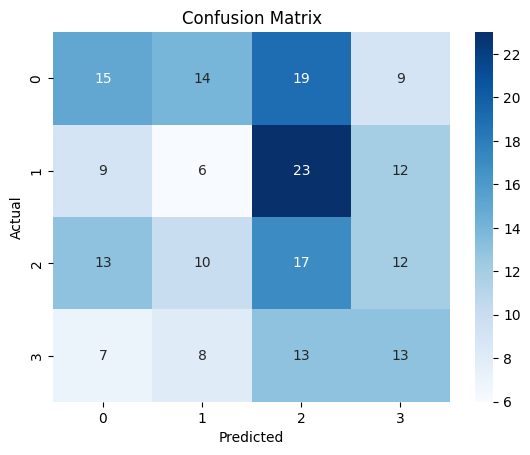

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
#The model achieved 25.5% accuracy, indicating low prediction performance.
#The confusion matrix and classification report show that the model struggles to correctly classify the four classes,
#with relatively low precision, recall, and F1-scores across all categories.

In [ ]:
# imporve we do

In [ ]:
# 1. Feature Engineering
df['Engagement_Score'] = df['Session_Duration'] * df['Pages_Viewed'] #That customer is more engaged with the website.
df['Pages_per_Min'] = df['Pages_Viewed'] / (df['Session_Duration'] + 1) #How fast a user browses pages.

In [ ]:
# 2. Simplify Membership Classes
df['Membership_Level'] = df['Membership_Level'].replace({2:1,3:1})#It converts multiple membership levels into two classes.

In [ ]:
# 3. Label Encoding
le = LabelEncoder()
df['Device_Type'] = le.fit_transform(df['Device_Type'])

In [ ]:
# 4. Define Features and Target
X = df[['Age','Session_Duration','Pages_Viewed','Purchase_Amount',
        'Device_Type','Engagement_Score','Pages_per_Min']]

y = df['Membership_Level']

In [ ]:
# 5. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 6. Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 7. Logistic Regression Model
model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# 8. Prediction
y_pred = model.predict(X_test)

In [ ]:
# 9. Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.55

Confusion Matrix:
[[31 26]
 [64 79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.54      0.41        57
           1       0.75      0.55      0.64       143

    accuracy                           0.55       200
   macro avg       0.54      0.55      0.52       200
weighted avg       0.63      0.55      0.57       200



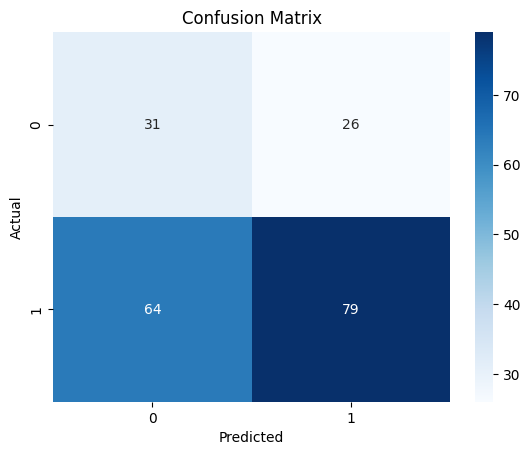

In [ ]:
# 10. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
#The confusion matrix shows that the model correctly predicted 31 Class-0 and 79 Class-1 samples,
# but several misclassifications occurred, giving an overall accuracy of 55%.

In [ ]:
#The model achieved 55% accuracy.
#The confusion matrix shows correct predictions for both classes, but the model performs better in predicting Class 1 than Class 0.

In [ ]:
#knn

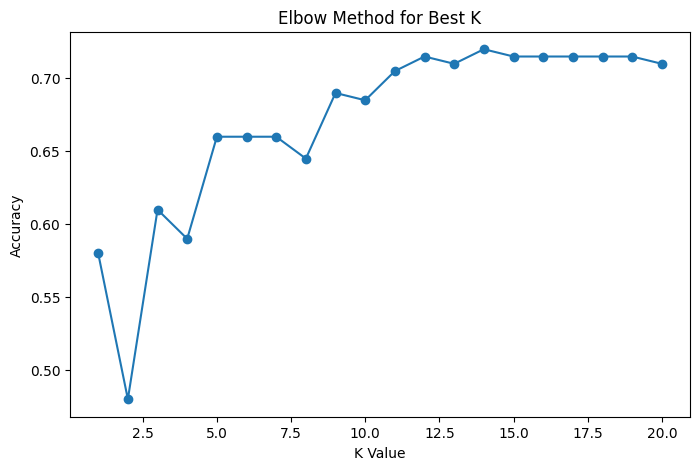

Best Accuracy: 0.72
Best K: 14


In [ ]:
# find k using elbow method
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracy = []

# Testing K values from 1 to 20
for k in range(1,21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracy.append(acc)

# Plot elbow graph
plt.figure(figsize=(8,5))
plt.plot(range(1,21), accuracy, marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Elbow Method for Best K")

plt.show()

print("Best Accuracy:", max(accuracy))
print("Best K:", accuracy.index(max(accuracy)) + 1)

In [ ]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Features and Target
X = df[['Age','Session_Duration','Pages_Viewed','Purchase_Amount',
        'Device_Type','Engagement_Score','Pages_per_Min']]

y = df['Membership_Level']


In [ ]:

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Feature Scaling (very important for KNN)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# KNN Model with best K
model = KNeighborsClassifier(n_neighbors=14)

model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=14)

In [ ]:
# Prediction
y_pred = model.predict(X_test)

In [ ]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.72

Confusion Matrix:
[[  3  54]
 [  2 141]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.05      0.10        57
           1       0.72      0.99      0.83       143

    accuracy                           0.72       200
   macro avg       0.66      0.52      0.47       200
weighted avg       0.69      0.72      0.62       200



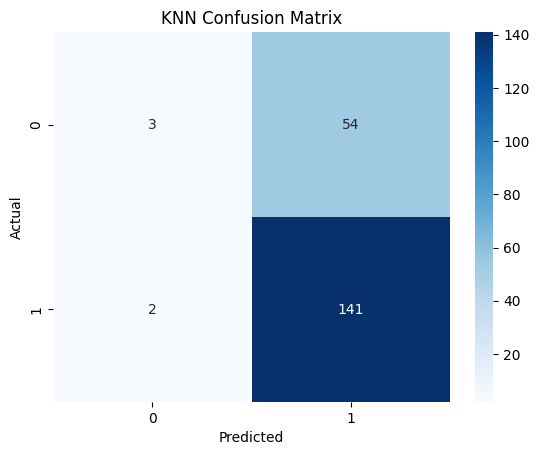

In [ ]:

# Heatmap
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()